/tmp/ipykernel_13361/2016265362.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  date = pd.date_range(sdate, edate, freq = 'M') + datetime.timedelta(1)


,value
1991-01-01,106.20
1991-02-01,104.80
1991-03-01,106.30
1991-04-01,163.50
1991-05-01,103.00
...,...
2025-10-01,100.50
2025-11-01,100.42
2025-12-01,100.32
2026-01-01,101.62


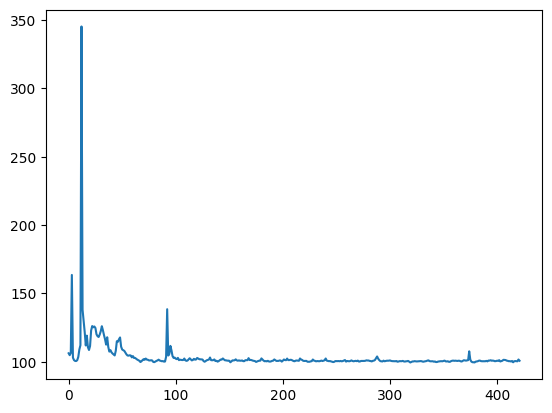

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings

df = pd.read_excel('ipc_mes_02-2026.xlsx', '01')
df = df.loc[4:15]

import datetime
import matplotlib.pyplot as plt
data = np.array(df.drop('Индексы потребительских цен на товары и услуги1) по Российской Федерации в 1991-2026*)гг.', axis = 1))
data = pd.DataFrame(data.flatten(order = 'f')).astype(float).dropna()
sdate = datetime.datetime(1990, 12, 1)
year = len(data) // 12 + 1991
month = len(data) % 12
edate = datetime.datetime(year, month, 1)
date = pd.date_range(sdate, edate, freq = 'M') + datetime.timedelta(1)
plt.plot(data[0])
data = data.dropna()
data.index = date
df = data.copy()
df.columns = ['value']
df

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from dateutil.relativedelta import relativedelta
def train_sarima_model(data, forecast_steps=12):
  forecast_horizon = forecast_steps
  window_size = len(data)
  monthly_dates = []
  for i in range(1, 13):
      next_date = data.index[-1] + relativedelta(months=i)
      monthly_dates.append(next_date)
  actuals = []
  for i in range(len(data)):
    actuals.append(data.iloc[i, 0])
  actuals = pd.DataFrame(actuals, index = data.index[-len(actuals):])
  forecast = []
  for i in range(len(data), len(data) + 1):
    forecasts_aux = []
    trivial_aux = []
    for m in range(1, forecast_horizon + 1):
      forc = []
      var = []
      for k in range(1, 5):
          p_max = 0.01
          df_aux = data.iloc[i - window_size // k:i, 0].copy()
          while np.sum(np.abs(df_aux - np.mean(df_aux)) / np.std(df_aux) > 3) > 0:
              df_aux[(df_aux - np.mean(df_aux)) / np.std(df_aux) > 3] = np.mean(df_aux) + 1.9 * np.std(df_aux)
              df_aux[(df_aux - np.mean(df_aux)) / np.std(df_aux) < -3] = np.mean(df_aux) - 1.9 * np.std(df_aux)
          train = pd.DataFrame(df_aux)
          if m <= 9:
              lags = [m, m + 1, m + 2, 12]
          elif m == 10:
              lags = [m, m + 1, 12]
          elif m == 11:
              lags = [m, 12]
          elif m == 12:
              lags = [12]
          X_p = [1]
          for j in lags:
              train['y_lag' + str(j)] = df_aux.shift(j)
              X_p.append(list(df_aux)[-j + m - 1])
          X_p = pd.DataFrame(np.array(X_p).reshape(1, -1), columns = train.columns)
          spisok = []
          matrix = train.corr()
          cor_max = 0.7
          target = 'value'
          for k in matrix.columns:
              for p in matrix.index:
                  if k != p and k != target and p != target:
                      if np.abs(matrix[k][p]) > cor_max:
                          if np.abs(matrix[target][p]) > np.abs(matrix[target][k]):
                              spisok.append(k)
                          else:
                              spisok.append(p)
          spisok = set(spisok)
          train = train.drop(spisok, axis = 1)

          X_p = X_p.drop(spisok, axis = 1)
          X_p = list(X_p.loc[0])

          train = train.dropna()
          model = sm.OLS(train['value'], sm.add_constant(train.drop('value', axis = 1))).fit()
          X = train.drop('value', axis = 1)
          while np.max(model.pvalues[1:]) > p_max:
              X = X.drop(X.columns[np.argmax(model.pvalues[1:])], axis = 1)
              X_p.pop(np.argmax(model.pvalues[1:]) + 1)
              model = sm.OLS(train['value'], sm.add_constant(X)).fit()

          forc.append(model.predict(X_p)[0])
          var.append(model.mse_resid)
      forecasts_aux.append(np.sum(np.array(forc) / np.array(var)) / np.sum(1 / np.array(var)))
      trivial_aux.append(np.median(data[i-12:i]))
      forecast.append(forecasts_aux[m - 1])
  forecast = pd.DataFrame(forecast, index = monthly_dates)

  return forecast, actuals

data = df - 100 # преобразовываем входные данные по ИПЦ

forc, act = train_sarima_model(data, forecast_steps=12)
forc

,0
2026-03-01,0.655109
2026-04-01,0.554826
2026-05-01,0.487549
2026-06-01,0.413715
2026-07-01,0.530554
2026-08-01,0.221225
2026-09-01,0.451236
2026-10-01,0.520686
2026-11-01,0.482551
2026-12-01,0.450510


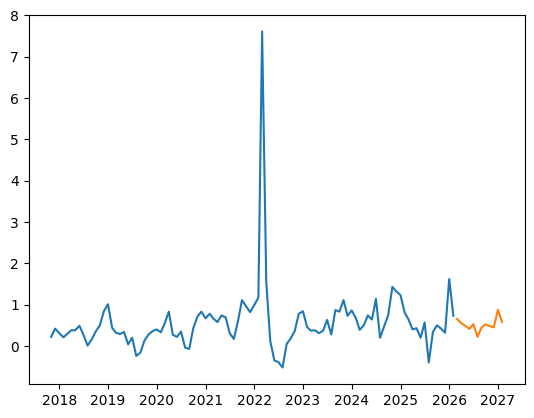

In [ ]:
plt.plot(act[-100:])
plt.plot(forc)